In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import numpy as np
import pandas as pd
import os
import re
import string

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import silhouette_score
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression

sns.set(style="whitegrid", context="talk")

# List files to confirm dataset name
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

df = pd.read_csv('/kaggle/input/datasets/asaniczka/tmdb-movies-dataset-2023-930k-movies/TMDB_movie_dataset_v11.csv')

# Quick peek
print(df.head())
print(df.columns)
print(df.shape)


import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/asaniczka/tmdb-movies-dataset-2023-930k-movies/TMDB_movie_dataset_v11.csv
       id            title  vote_average  vote_count    status release_date  \
0   27205        Inception         8.364       34495  Released   2010-07-15   
1  157336     Interstellar         8.417       32571  Released   2014-11-05   
2     155  The Dark Knight         8.512       30619  Released   2008-07-16   
3   19995           Avatar         7.573       29815  Released   2009-12-15   
4   24428     The Avengers         7.710       29166  Released   2012-04-25   

      revenue  runtime  adult                     backdrop_path  ...  \
0   825532764      148  False  /8ZTVqvKDQ8emSGUEMjsS4yHAwrp.jpg  ...   
1   701729206      169  False  /pbrkL804c8yAv3zBZR4QPEafpAR.jpg  ...   
2  1004558444      152  False  /nMKdUUepR0i5zn0y1T4CsSB5chy.jpg  ...   
3  2923706026      162  False  /vL5LR6WdxWPjLPFRLe133jXWsh5.jpg  ...   
4  1518815515      143  False  /9BBTo63ANSmhC4e6r62OJFuK2GL.jpg  ...

In [2]:
# Keep only rows with non-null titles
df = df[df['title'].notna()].copy()
df = df[~df['adult']]

import string

df['title_stripped'] = df['title'].astype(str).str.strip()
df['title_length_chars'] = df['title_stripped'].str.len()
df['title_word_count'] = df['title_stripped'].str.split().str.len()

In [3]:


# First character, may be empty or NaN after conversion
df['title_first_char'] = df['title_stripped'].str[0].str.upper()

def map_first_char(c):
    # Handle NaN / non-string
    if not isinstance(c, str) or len(c) == 0:
        return 'OTHER'
    return c if c in string.ascii_uppercase else 'OTHER'

df['title_first_char_group'] = df['title_first_char'].apply(map_first_char)


df['title_has_number'] = df['title_stripped'].str.contains(r'\d', regex=True)



In [4]:
# Simple bins for word count and length (good for dashboards)
df['title_word_bin'] = pd.cut(
    df['title_word_count'],
    bins=[0, 1, 3, 5, 8, 100],
    labels=['1 word', '2-3', '4-5', '6-8', '9+']
)

df['title_length_bin'] = pd.cut(
    df['title_length_chars'],
    bins=[0, 10, 20, 30, 40, 300],
    labels=['<=10', '11-20', '21-30', '31-40', '41+']
)

# Inspect distributions
print(df[['title_length_chars', 'title_word_count']].describe())

       title_length_chars  title_word_count
count        1.469969e+06      1.469969e+06
mean         2.018355e+01      3.486458e+00
std          1.460533e+01      2.528991e+00
min          0.000000e+00      0.000000e+00
25%          1.100000e+01      2.000000e+00
50%          1.700000e+01      3.000000e+00
75%          2.500000e+01      4.000000e+00
max          3.240000e+02      5.800000e+01


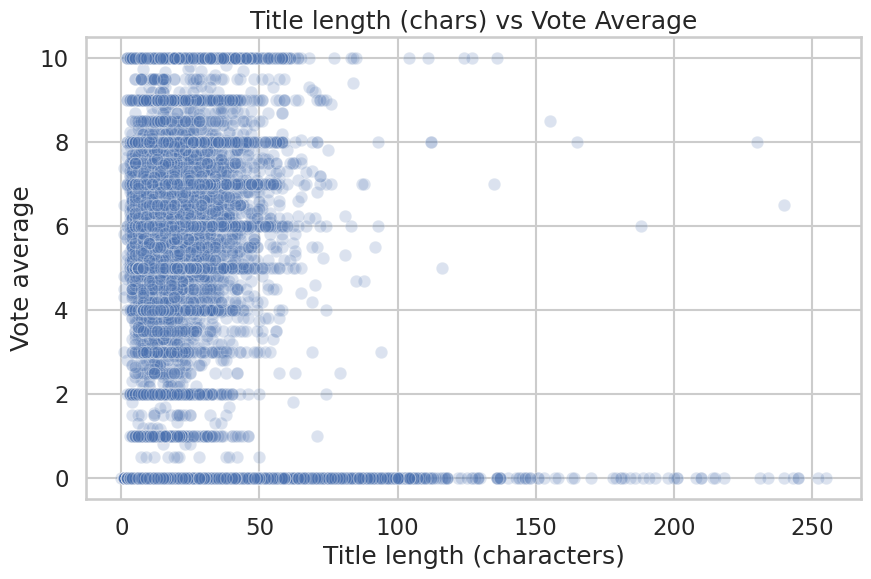

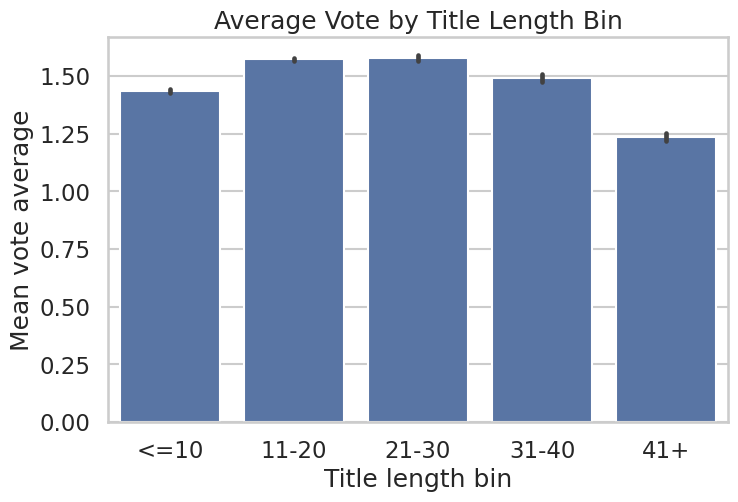

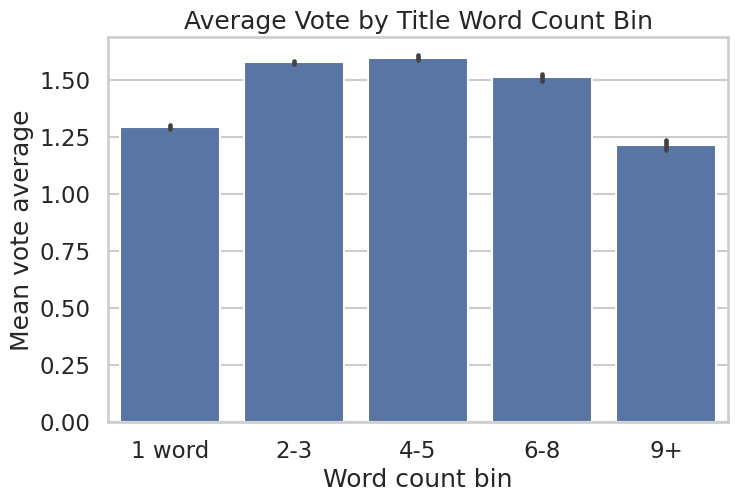

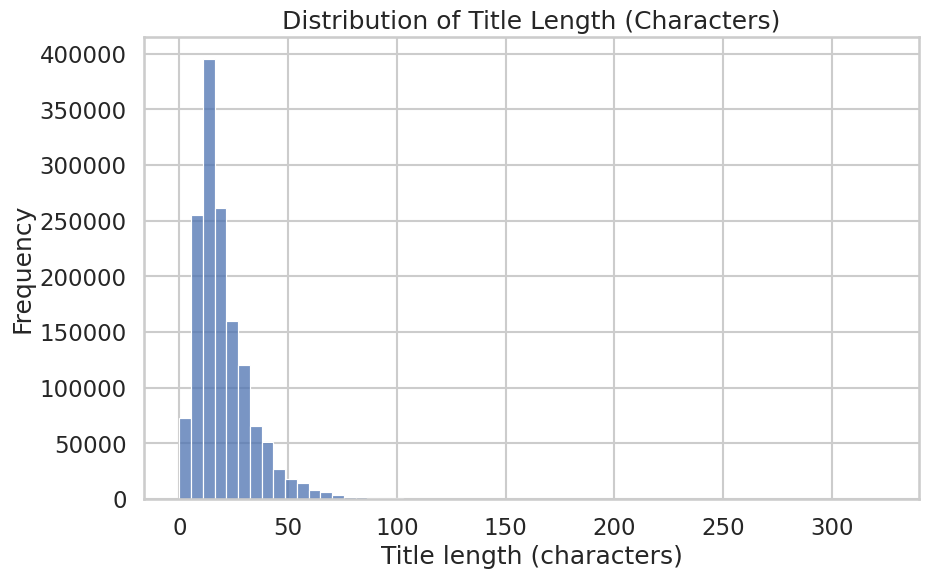

                         count      mean
title_first_char_group                  
T                       214037  1.841590
W                        41760  1.630942
J                        23658  1.626826
X                         1494  1.608461
A                       100678  1.570448
M                        85514  1.565179
B                        82209  1.554337
L                        78849  1.553467
R                        45241  1.552735
G                        37215  1.539376
K                        27534  1.531909
Y                        10390  1.525439
C                        73077  1.515911
D                        74638  1.515576
S                       113822  1.514321
F                        49330  1.510517
H                        51982  1.495782
E                        42115  1.486820
I                        43218  1.483898
P                        61281  1.471562


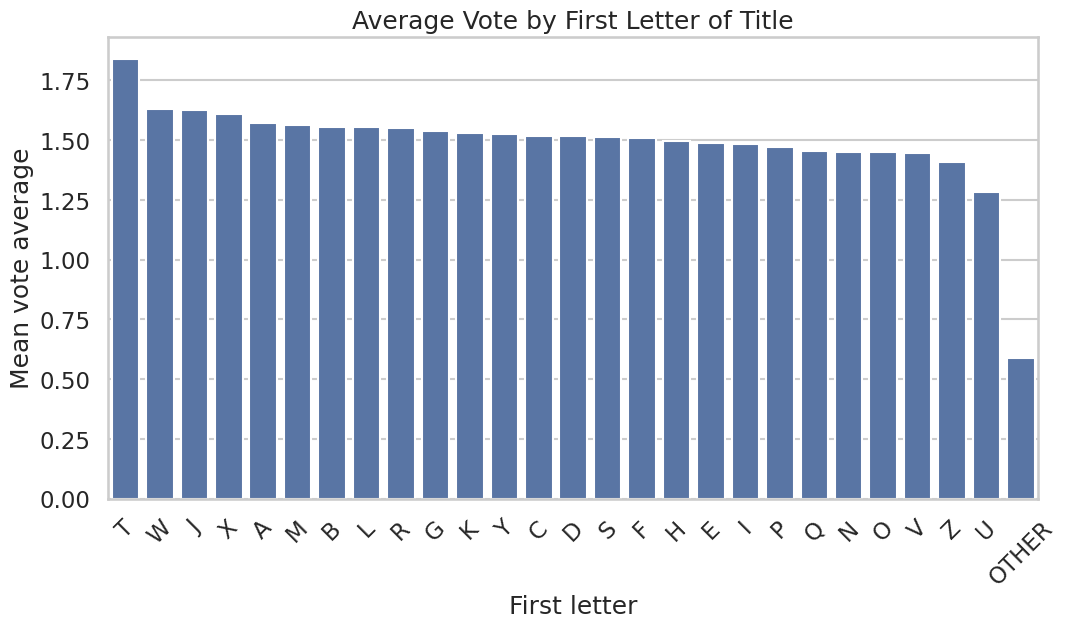

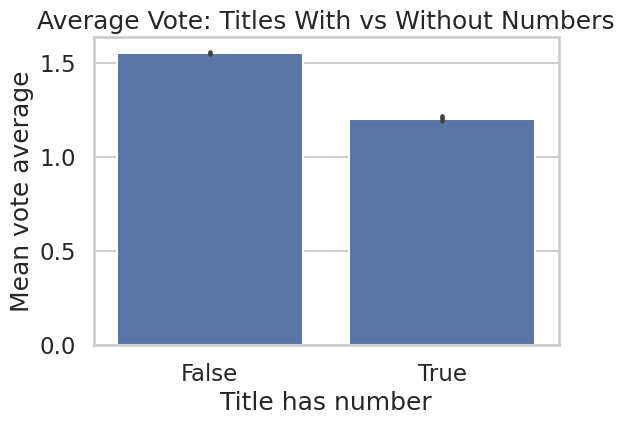

In [5]:
# Title length vs. vote_average
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df.sample(min(50000, len(df))),  # sample for speed
    x='title_length_chars',
    y='vote_average',
    alpha=0.2
)
plt.title('Title length (chars) vs Vote Average')
plt.xlabel('Title length (characters)')
plt.ylabel('Vote average')
plt.show()

# Average score by title length bin
plt.figure(figsize=(8, 5))
sns.barplot(
    data=df,
    x='title_length_bin',
    y='vote_average',
    estimator=np.mean,
    order=['<=10', '11-20', '21-30', '31-40', '41+']
)
plt.title('Average Vote by Title Length Bin')
plt.xlabel('Title length bin')
plt.ylabel('Mean vote average')
plt.show()

# Average score by title word bin
plt.figure(figsize=(8, 5))
sns.barplot(
    data=df,
    x='title_word_bin',
    y='vote_average',
    estimator=np.mean,
)
plt.title('Average Vote by Title Word Count Bin')
plt.xlabel('Word count bin')
plt.ylabel('Mean vote average')
plt.show()

# Weird peaks in title length distribution
plt.figure(figsize=(10, 6))
sns.histplot(df['title_length_chars'], bins=60, kde=False)
plt.title('Distribution of Title Length (Characters)')
plt.xlabel('Title length (characters)')
plt.ylabel('Frequency')
plt.show()

# First-letter effects
first_letter_stats = (
    df.groupby('title_first_char_group')['vote_average']
      .agg(['count', 'mean'])
      .sort_values('mean', ascending=False)
)
print(first_letter_stats.head(20))

plt.figure(figsize=(12, 6))
sns.barplot(
    data=first_letter_stats.reset_index(),
    x='title_first_char_group',
    y='mean'
)
plt.title('Average Vote by First Letter of Title')
plt.xlabel('First letter')
plt.ylabel('Mean vote average')
plt.xticks(rotation=45)
plt.show()

# Numbers in title vs score
plt.figure(figsize=(6, 4))
sns.barplot(
    data=df,
    x='title_has_number',
    y='vote_average',
    estimator=np.mean
)
plt.title('Average Vote: Titles With vs Without Numbers')
plt.xlabel('Title has number')
plt.ylabel('Mean vote average')
plt.show()

In [6]:
length_group = (
    df.groupby('title_length_chars')['vote_average']
      .agg(['count', 'mean'])
      .sort_index()
)
print(length_group.loc[8:20])  # small window around 10–13 characters

                    count      mean
title_length_chars                 
8                   52829  1.472675
9                   56807  1.510925
10                  60182  1.515258
11                  62082  1.525653
12                  64992  1.558547
13                  68046  1.566529
14                  67990  1.578158
15                  67161  1.568109
16                  64770  1.575338
17                  62119  1.580092
18                  57162  1.607440
19                  52362  1.580677
20                  47421  1.585119


In [7]:
# Basic tokenizer for titles
def clean_title(text):
    text = text.lower()
    text = re.sub(r'[^a-z0-9\s]', ' ', text)  # keep letters/numbers
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['title_clean'] = df['title_stripped'].apply(clean_title)

# Simple keyword list (split on spaces, remove trivial tokens)
stop_words = {
    'the', 'a', 'an', 'of', 'and', 'in', 'on', 'for', 'to', 'with',
    'at', 'by', 'from', 'into', 'as', 'is', 'are', 'be'
}

def extract_keywords(text):
    tokens = text.split()
    return [t for t in tokens if t not in stop_words and len(t) > 2]

df['title_keywords'] = df['title_clean'].apply(extract_keywords)

# Explode keywords for frequency analysis
kw_df = df[['id', 'title', 'title_keywords']].explode('title_keywords')
kw_df = kw_df.dropna(subset=['title_keywords'])

# Top keywords overall
top_keywords = (
    kw_df['title_keywords']
         .value_counts()
         .head(50)
)
print(top_keywords)

title_keywords
live         18133
love         17650
you          14264
man          10924
life         10054
night         9741
story         9606
die           9291
der           9146
world         8649
one           8518
big           8186
day           8106
black         7930
all           7609
time          7323
les           7260
sex           7058
last          6945
girl          6882
new           6687
how           6546
film          6238
girls         6198
who           5950
your          5860
movie         5810
little        5624
out           5337
del           5233
that          5198
not           5182
her           5118
house         5028
des           4991
christmas     4903
home          4901
death         4798
first         4791
best          4682
vol           4609
what          4563
don           4401
two           4326
this          4323
red           4207
city          4140
part          4127
white         4100
dead          4082
Name: count, dtype: int64


In [8]:
# TF-IDF representation of titles
tfidf = TfidfVectorizer(
    max_features=20000,
    min_df=5,
    max_df=0.6,
    stop_words='english'
)

X_tfidf = tfidf.fit_transform(df['title_clean'])

print("TF-IDF shape:", X_tfidf.shape)

# Choose number of clusters
k = 20

kmeans = KMeans(
    n_clusters=k,
    random_state=42,
    n_init='auto'
)
df['title_cluster'] = kmeans.fit_predict(X_tfidf)

from sklearn.metrics import silhouette_score

sample_idx = np.random.choice(X_tfidf.shape[0], size=min(50000, X_tfidf.shape[0]), replace=False)
score = silhouette_score(X_tfidf[sample_idx], df['title_cluster'].iloc[sample_idx])
print("Silhouette score:", score)

def top_terms_per_cluster(model, vectorizer, n_terms=15):
    terms = np.array(vectorizer.get_feature_names_out())
    centers = model.cluster_centers_
    for i in range(model.n_clusters):
        center_terms = terms[np.argsort(centers[i])[::-1][:n_terms]]
        print(f"\nCluster {i}:")
        print(", ".join(center_terms))

top_terms_per_cluster(kmeans, tfidf, n_terms=15)

cluster_summary = (
    df.groupby('title_cluster')
      .agg(
          count=('id', 'count'),
          mean_vote=('vote_average', 'mean'),
          mean_runtime=('runtime', 'mean'),
          mean_popularity=('popularity', 'mean')
      )
      .sort_values('mean_vote', ascending=False)
)
print(cluster_summary.head(10))

TF-IDF shape: (1469969, 20000)
Silhouette score: 0.07071177796789971

Cluster 0:
diaries, babysitter, lesbian, secret, red, taboo, shoe, cheerleader, princess, vampire, video, hotel, real, bareback, motorcycle

Cluster 1:
investigation, paranormal, special, facebook, held, self, guide, time, unit, anal, site, ramana, record, episode, counter

Cluster 2:
ghost, story, stories, town, house, canterville, rider, train, holy, school, vengeful, ship, shell, videos, light

Cluster 3:
love, story, true, song, teens, big, time, death, life, hate, girls, like, stories, affair, fall

Cluster 4:
la, live, el, man, life, die, der, day, time, story, world, black, big, girl, les

Cluster 5:
pop, festival, shots, iggy, cherry, house, live, vol, goes, star, la, doki, culture, new, music

Cluster 6:
uma, ria, hist, vida, vez, em, noite, era, para, mais, na, mulher, um, mem, rio

Cluster 7:
dark, night, light, room, meat, moon, matter, secrets, knight, shot, horse, web, angel, desires, house

Cluster 8:


In [9]:
# Inspect genres column name/format
print(df['genres'].head())

# Extract a primary genre (simplistic: first genre name in the string)
def extract_primary_genre(genre_str):
    if pd.isna(genre_str) or genre_str.strip() == "":
        return "Unknown"
    # Many TMDB exports are like: [{"id":18,"name":"Drama"}, ...]
    # Crude extraction: take text between "name":" and next quote
    match = re.search(r'"name"\s*:\s*"([^"]+)"', genre_str)
    if match:
        return match.group(1)
    # Fallback: take first word token
    return genre_str.split(',')[0].strip()

if 'genres' in df.columns:
    df['primary_genre'] = df['genres'].apply(extract_primary_genre)
else:
    df['primary_genre'] = 'Unknown'

print(df['primary_genre'].value_counts().head(20))

# Keyword frequencies per genre
kw_genre_df = df[['primary_genre', 'title_keywords']].explode('title_keywords')
kw_genre_df = kw_genre_df.dropna(subset=['title_keywords'])

genre_keyword_counts = (
    kw_genre_df.groupby(['primary_genre', 'title_keywords'])
               .size()
               .reset_index(name='count')
)

# Top keywords for a few major genres
for g in genre_keyword_counts['primary_genre'].value_counts().head(5).index:
    sub = genre_keyword_counts[genre_keyword_counts['primary_genre'] == g]
    print(f"\nTop keywords in titles for genre: {g}")
    print(
        sub.sort_values('count', ascending=False)
           .head(20)
    )

0             Action, Science Fiction, Adventure
1              Adventure, Drama, Science Fiction
2                 Drama, Action, Crime, Thriller
3    Action, Adventure, Fantasy, Science Fiction
4             Science Fiction, Action, Adventure
Name: genres, dtype: object
primary_genre
Unknown            654628
Drama              194022
Documentary        191841
Comedy             114104
Animation           58679
Horror              46951
Music               39649
Action              33998
Romance             23535
Thriller            21432
Crime               17841
Family              11429
Science Fiction     11232
Adventure           10539
Fantasy              9682
Mystery              7743
TV Movie             7135
Western              6521
History              5008
War                  4000
Name: count, dtype: int64

Top keywords in titles for genre: Unknown
       primary_genre title_keywords  count
566675       Unknown           live   7669
567871       Unknown           love   

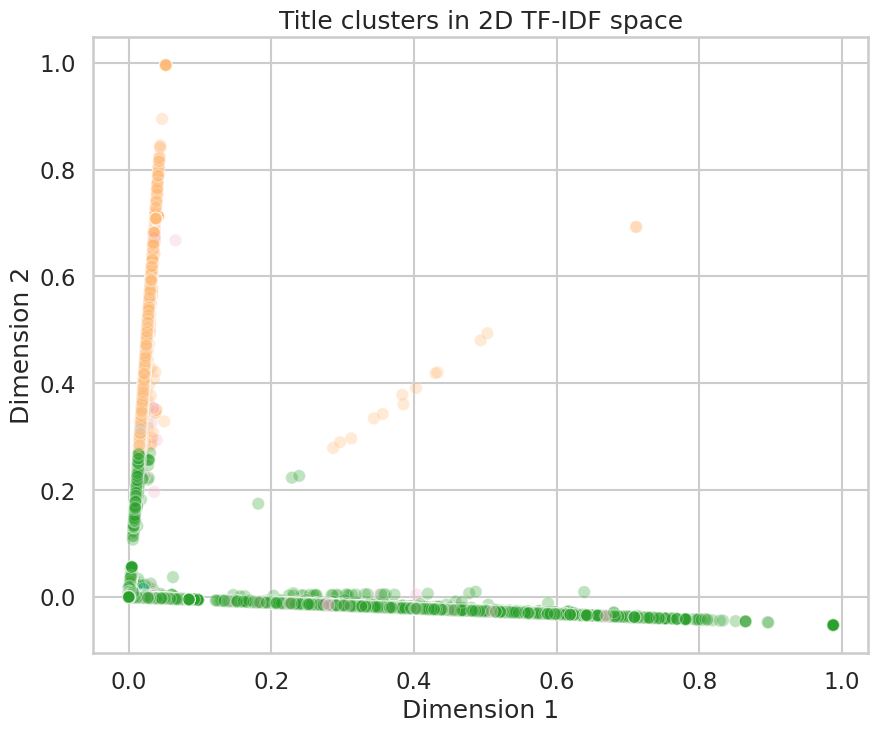

In [10]:
svd = TruncatedSVD(n_components=2, random_state=42)
X_2d = svd.fit_transform(X_tfidf)

df['title_dim1'] = X_2d[:, 0]
df['title_dim2'] = X_2d[:, 1]

plt.figure(figsize=(10, 8))
sns.scatterplot(
    x=df['title_dim1'],
    y=df['title_dim2'],
    hue=df['title_cluster'],
    palette='tab20',
    alpha=0.3,
    legend=False
)
plt.title('Title clusters in 2D TF-IDF space')
plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')
plt.show()

RF train R^2: 0.9561248715464936
RF test R^2: 0.8727926063663627
vote_count            0.904972
popularity            0.034841
runtime               0.025920
title_length_chars    0.023298
title_word_count      0.009188
title_has_number      0.001781
dtype: float64


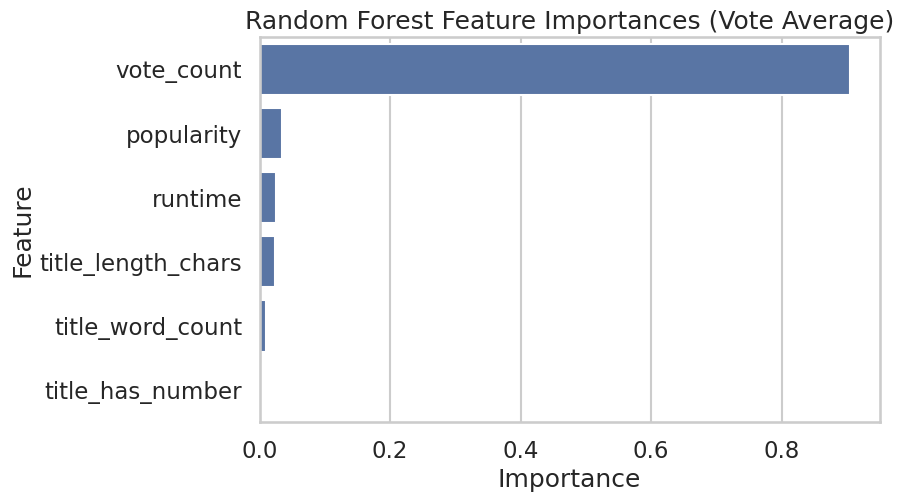

LR train R^2: 0.07508830905795405
LR test R^2: 0.06225262105809237


In [11]:
# Feature set from titles + a bit of metadata
feature_cols = [
    'title_length_chars',
    'title_word_count',
    'title_has_number',
    'runtime',
    'vote_count',
    'popularity'
]

# Ensure numeric
for col in feature_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df_model = df.dropna(subset=feature_cols + ['vote_average']).copy()

X = df_model[feature_cols]
y = df_model['vote_average']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Random Forest
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

print("RF train R^2:", rf.score(X_train, y_train))
print("RF test R^2:", rf.score(X_test, y_test))

# Feature importance
importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)
print(importances)

plt.figure(figsize=(8, 5))
sns.barplot(x=importances.values, y=importances.index)
plt.title('Random Forest Feature Importances (Vote Average)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

# Baseline linear regression
lr = LinearRegression()
lr.fit(X_train, y_train)
print("LR train R^2:", lr.score(X_train, y_train))
print("LR test R^2:", lr.score(X_test, y_test))

In [12]:
X_len = df_model[['title_length_chars', 'title_word_count']]
y_len = df_model['vote_average']

lr2 = LinearRegression()
lr2.fit(X_len, y_len)

print("Coefficients (length, word_count):", lr2.coef_)
print("Intercept:", lr2.intercept_)
print("R^2:", lr2.score(X_len, y_len))

Coefficients (length, word_count): [-0.02350292  0.12051651]
Intercept: 1.5642947198509818
R^2: 0.002252698100134287


## Failure

In [13]:
# Numeric clean-up
for col in ['revenue', 'budget', 'vote_average', 'vote_count', 'popularity', 'runtime']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Year extraction from release_date
df['release_year'] = pd.to_datetime(df['release_date'], errors='coerce').dt.year

# Simple ROI metric (handle zero/NaN)
df['roi'] = np.where(
    (df['budget'] > 0) & (~df['budget'].isna()),
    df['revenue'] / df['budget'],
    np.nan
)

# Define "failure" thresholds (tunable)
df['is_commercial_flop'] = (df['roi'] < 0.5) & df['budget'].notna()  # spent twice what it earned
df['is_critical_flop'] = df['vote_average'] < 4.0
df['is_audience_flop'] = (df['popularity'] < df['popularity'].quantile(0.2)) & (df['vote_count'] < df['vote_count'].quantile(0.2))

# Combined failure flag
df['is_flop_any'] = df[['is_commercial_flop', 'is_critical_flop', 'is_audience_flop']].any(axis=1)

df[['title', 'release_year', 'budget', 'revenue', 'roi', 'vote_average', 'is_flop_any']].head()

,title,release_year,budget,revenue,roi,vote_average,is_flop_any
0,Inception,2010.0,160000000,825532764,5.159580,8.364,False
1,Interstellar,2014.0,165000000,701729206,4.252904,8.417,False
2,The Dark Knight,2008.0,185000000,1004558444,5.430046,8.512,False
3,Avatar,2009.0,237000000,2923706026,12.336312,7.573,False
4,The Avengers,2012.0,220000000,1518815515,6.903707,7.710,False


                 failure_rate  movie_count
primary_genre                             
Unknown              0.917836       654628
Documentary          0.779969       191841
Horror               0.759877        46951
Animation            0.736584        58679
Music                0.715529        39649
Science Fiction      0.702813        11232
Fantasy              0.697377         9682
Drama                0.677995       194022
History              0.662540         5008
Mystery              0.654398         7743
Romance              0.647844        23535
Thriller             0.642217        21432
Western              0.628738         6521
Comedy               0.611758       114104
Family               0.605652        11429
Crime                0.595594        17841
Action               0.583505        33998
Adventure            0.552614        10539
War                  0.549000         4000
TV Movie             0.540154         7135
                  failure_rate   count
title_length_bi

/tmp/ipykernel_254/1696437228.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('title_length_bin')['is_flop_any']
/tmp/ipykernel_254/1696437228.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('title_word_bin')['is_flop_any']


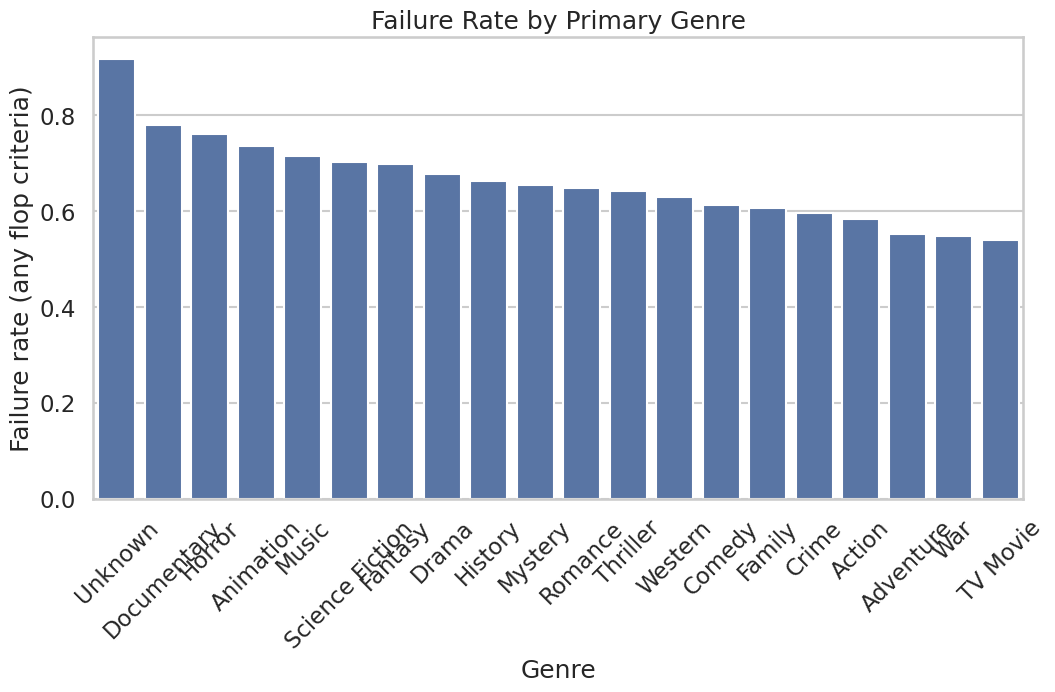

In [14]:
# Failure rate by primary genre
genre_failure = (
    df.groupby('primary_genre')['is_flop_any']
      .agg(['mean', 'count'])
      .rename(columns={'mean': 'failure_rate', 'count': 'movie_count'})
      .sort_values('failure_rate', ascending=False)
)
print(genre_failure.head(20))

# Failure rate by title length bin
length_failure = (
    df.groupby('title_length_bin')['is_flop_any']
      .agg(['mean', 'count'])
      .rename(columns={'mean': 'failure_rate'})
)
print(length_failure)

# Failure rate by word count bin
word_failure = (
    df.groupby('title_word_bin')['is_flop_any']
      .agg(['mean', 'count'])
      .rename(columns={'mean': 'failure_rate'})
)
print(word_failure)

# Plot example: failure rate by genre
plt.figure(figsize=(12, 6))
sns.barplot(
    data=genre_failure.reset_index(),
    x='primary_genre',
    y='failure_rate'
)
plt.title('Failure Rate by Primary Genre')
plt.xlabel('Genre')
plt.ylabel('Failure rate (any flop criteria)')
plt.xticks(rotation=45)
plt.show()

In [15]:
# Filter to movies with a year and revenue > 0
df_valid_rev = df[(df['release_year'].notna()) & (df['revenue'] > 0)].copy()

# Top-grossing movie for each year
top_grossing = (
    df_valid_rev.sort_values(['release_year', 'revenue'], ascending=[True, False])
               .groupby('release_year')
               .head(1)[['release_year', 'id', 'title', 'revenue', 'primary_genre', 'title_keywords']]
               .reset_index(drop=True)
)

print(top_grossing.head(20))

    release_year       id                                              title  \
0         1800.0  1492510  Juliet and Romeo - 1231 ☆*: .｡. o(≧▽≦)o .｡.:*☆...   
1         1898.0  1381714                     New York Stories: Life Lessons   
2         1900.0  1482890                                Man in the Dunes #2   
3         1905.0  1301405                     What is Seen Through a Keyhole   
4         1911.0  1180455                             Water, Klimaat en Film   
5         1913.0    96128                                   Traffic in Souls   
6         1914.0   572090                                 Neptune's Daughter   
7         1915.0      618                              The Birth of a Nation   
8         1916.0    30266                       20,000 Leagues Under the Sea   
9         1918.0    54242                                             Mickey   
10        1919.0    70801                                    Daddy-Long-Legs   
11        1920.0    31509               

    base_year  target_year                                        top_title  \
0      1898.0       1899.0                   New York Stories: Life Lessons   
1      1900.0       1901.0                              Man in the Dunes #2   
2      1905.0       1906.0                   What is Seen Through a Keyhole   
3      1911.0       1912.0                           Water, Klimaat en Film   
4      1913.0       1914.0                                 Traffic in Souls   
5      1914.0       1915.0                               Neptune's Daughter   
6      1915.0       1916.0                            The Birth of a Nation   
7      1916.0       1917.0                     20,000 Leagues Under the Sea   
8      1918.0       1919.0                                           Mickey   
9      1919.0       1920.0                                  Daddy-Long-Legs   
10     1920.0       1921.0                                    Way Down East   
11     1921.0       1922.0                          

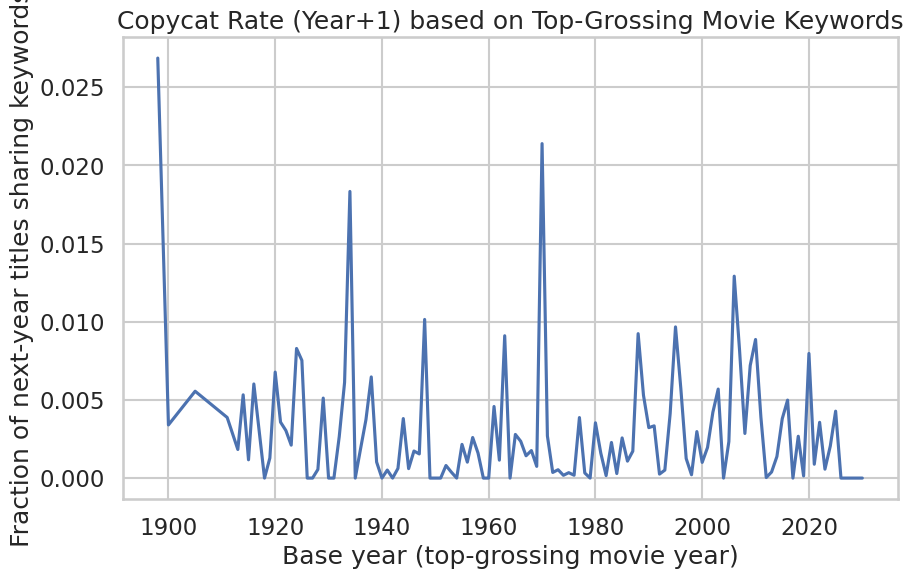

In [16]:
# Prepare per-year title keyword lists
year_kw_df = df[['release_year', 'id', 'title', 'title_keywords']].explode('title_keywords')
year_kw_df = year_kw_df.dropna(subset=['release_year', 'title_keywords'])

# Function to compute copycat stats for a given lag (e.g., Y+1)
def compute_copycat_stats(lag=1):
    rows = []

    for _, row in top_grossing.iterrows():
        base_year = row['release_year']
        target_year = base_year + lag
        base_keywords = set(row['title_keywords'] or [])

        if not base_keywords or pd.isna(target_year):
            continue

        # Titles in target year
        target_titles = df[df['release_year'] == target_year].copy()
        if target_titles.empty:
            continue

        # How many titles share at least one keyword with top-grossing movie of base_year
        def has_overlap(kw_list):
            if not isinstance(kw_list, list):
                return False
            return len(base_keywords.intersection(kw_list)) > 0

        target_titles['copycat_like'] = target_titles['title_keywords'].apply(has_overlap)

        rows.append({
            'base_year': base_year,
            'target_year': target_year,
            'top_title': row['title'],
            'top_revenue': row['revenue'],
            'top_keywords': list(base_keywords),
            'target_movie_count': len(target_titles),
            'copycat_count': target_titles['copycat_like'].sum(),
            'copycat_rate': target_titles['copycat_like'].mean()
        })

    return pd.DataFrame(rows)

copycat_1yr = compute_copycat_stats(lag=1)
print(copycat_1yr.head(20))

plt.figure(figsize=(10, 6))
sns.lineplot(
    data=copycat_1yr,
    x='base_year',
    y='copycat_rate'
)
plt.title('Copycat Rate (Year+1) based on Top-Grossing Movie Keywords')
plt.xlabel('Base year (top-grossing movie year)')
plt.ylabel('Fraction of next-year titles sharing keywords')
plt.show()

    base_year  target_year    top_genre  target_total_movies  \
0      1898.0       1899.0        Drama                  335   
1      1900.0       1901.0      Western                  294   
2      1905.0       1906.0       Comedy                  360   
3      1911.0       1912.0  Documentary                 1547   
4      1913.0       1914.0        Crime                 1640   
5      1914.0       1915.0      Fantasy                 1690   
6      1915.0       1916.0        Drama                 1711   
7      1916.0       1917.0    Adventure                 1661   
8      1918.0       1919.0       Comedy                 1497   
9      1919.0       1920.0        Drama                 1559   
10     1920.0       1921.0        Drama                 1475   
11     1921.0       1922.0       Comedy                 1397   
12     1922.0       1923.0        Drama                 1314   
13     1923.0       1924.0       Comedy                 1424   
14     1924.0       1925.0       Comedy 

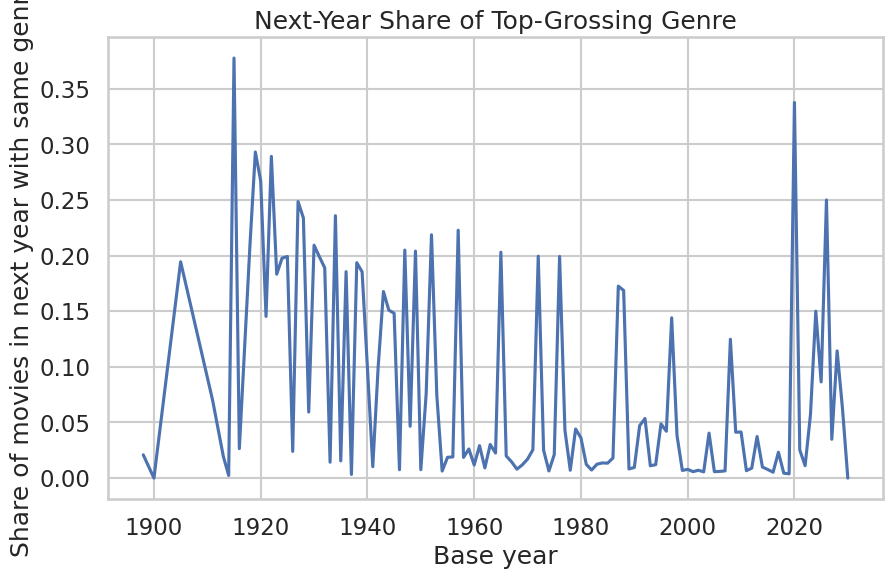

In [17]:
# For each year, record genre distribution
genre_year_counts = (
    df.dropna(subset=['primary_genre', 'release_year'])
      .groupby(['release_year', 'primary_genre'])
      .size()
      .reset_index(name='count')
)

# Merge in top-grossing info
top_grossing_genre = top_grossing[['release_year', 'primary_genre']].rename(
    columns={'release_year': 'base_year', 'primary_genre': 'top_genre'}
)

# For each base_year, look at target_year genre distribution and how the top_genre share changes
rows = []
for _, tg in top_grossing_genre.iterrows():
    base_year = tg['base_year']
    target_year = base_year + 1
    top_genre = tg['top_genre']

    target_genres = genre_year_counts[genre_year_counts['release_year'] == target_year]
    if target_genres.empty:
        continue

    total_count = target_genres['count'].sum()
    top_genre_count = target_genres[target_genres['primary_genre'] == top_genre]['count'].sum()

    rows.append({
        'base_year': base_year,
        'target_year': target_year,
        'top_genre': top_genre,
        'target_total_movies': total_count,
        'target_top_genre_movies': top_genre_count,
        'target_top_genre_share': top_genre_count / total_count if total_count > 0 else np.nan
    })

genre_copycat = pd.DataFrame(rows)
print(genre_copycat.head(20))

plt.figure(figsize=(10, 6))
sns.lineplot(
    data=genre_copycat,
    x='base_year',
    y='target_top_genre_share'
)
plt.title('Next-Year Share of Top-Grossing Genre')
plt.xlabel('Base year')
plt.ylabel('Share of movies in next year with same genre')
plt.show()

                   failure_rate  movie_count
copycat_prev_year                           
False                  0.792471      1466497
True                   0.672811         3472


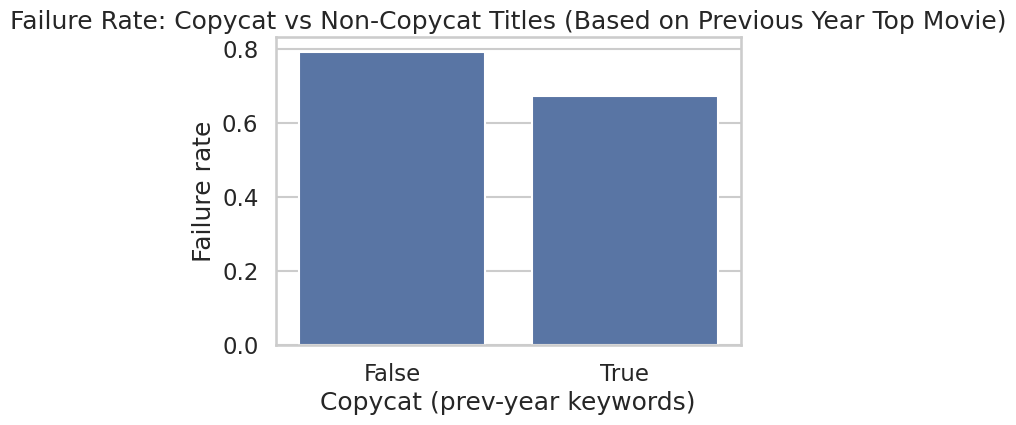

In [18]:
# Compute copycat flags per movie for Y+1 based on previous year top title
df['copycat_prev_year'] = False

# Create lookup: base_year -> keyword set of top-grossing movie
top_kw_by_year = {
    int(row['release_year']): set(row['title_keywords'] or [])
    for _, row in top_grossing.iterrows()
}

def is_copycat(row):
    year = row['release_year']
    if pd.isna(year):
        return False
    prev_year = int(year) - 1
    if prev_year not in top_kw_by_year:
        return False
    base_keywords = top_kw_by_year[prev_year]
    kw_list = row['title_keywords']
    if not isinstance(kw_list, list):
        return False
    return len(base_keywords.intersection(kw_list)) > 0

df['copycat_prev_year'] = df.apply(is_copycat, axis=1)

# Compare failure rates
copycat_stats = (
    df.groupby('copycat_prev_year')['is_flop_any']
      .agg(['mean', 'count'])
      .rename(columns={'mean': 'failure_rate', 'count': 'movie_count'})
)
print(copycat_stats)

plt.figure(figsize=(6, 4))
sns.barplot(
    data=copycat_stats.reset_index(),
    x='copycat_prev_year',
    y='failure_rate'
)
plt.title('Failure Rate: Copycat vs Non-Copycat Titles (Based on Previous Year Top Movie)')
plt.xlabel('Copycat (prev-year keywords)')
plt.ylabel('Failure rate')
plt.show()

## Average Title by Year

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import numpy as np
import pandas as pd
import os
import re
import string

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import silhouette_score
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression

sns.set(style="whitegrid", context="talk")

# List files to confirm dataset name
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

df = pd.read_csv('/kaggle/input/datasets/asaniczka/tmdb-movies-dataset-2023-930k-movies/TMDB_movie_dataset_v11.csv')

# Quick peek
print(df.head())
print(df.columns)
print(df.shape)


import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/asaniczka/tmdb-movies-dataset-2023-930k-movies/TMDB_movie_dataset_v11.csv
       id            title  vote_average  vote_count    status release_date  \
0   27205        Inception         8.364       34495  Released   2010-07-15   
1  157336     Interstellar         8.417       32571  Released   2014-11-05   
2     155  The Dark Knight         8.512       30619  Released   2008-07-16   
3   19995           Avatar         7.573       29815  Released   2009-12-15   
4   24428     The Avengers         7.710       29166  Released   2012-04-25   

      revenue  runtime  adult                     backdrop_path  ...  \
0   825532764      148  False  /8ZTVqvKDQ8emSGUEMjsS4yHAwrp.jpg  ...   
1   701729206      169  False  /pbrkL804c8yAv3zBZR4QPEafpAR.jpg  ...   
2  1004558444      152  False  /nMKdUUepR0i5zn0y1T4CsSB5chy.jpg  ...   
3  2923706026      162  False  /vL5LR6WdxWPjLPFRLe133jXWsh5.jpg  ...   
4  1518815515      143  False  /9BBTo63ANSmhC4e6r62OJFuK2GL.jpg  ...

In [3]:
# Keep only rows with non-null titles
df = df[df['title'].notna()].copy()


# 2) Optional: focus on a reasonable year range
# df = df[(df['release_year'] >= 1970) & (df['release_year'] <= 2024)]

# 3) For TF-IDF and clustering, sample
#N = 200_000  # or even 100k; enough for patterns without killing RAM
#if len(df) > N:
#    df_nlp = df.sample(N, random_state=42).copy()
#else:
#    df_nlp = df.copy()

import string

df['title_stripped'] = df['title'].astype(str).str.strip()
df['title_length_chars'] = df['title_stripped'].str.len()
df['title_word_count'] = df['title_stripped'].str.split().str.len()

In [4]:
def extract_primary_genre(genre_str):
    if pd.isna(genre_str) or genre_str.strip() == "":
        return "Unknown"
    match = re.search(r'"name"\s*:\s*"([^"]+)"', genre_str)
    if match:
        return match.group(1)
    return genre_str.split(',')[0].strip()

df['primary_genre'] = df['genres'].apply(extract_primary_genre)

# Optionally remove "Unknown" and/or explicit genres you don't want
genres_to_exclude = {"Unknown", "Adult"}  # adjust to taste
df_filtered = df[~df['primary_genre'].isin(genres_to_exclude)].copy()

In [41]:
# Ensure numeric
df_filtered['vote_count'] = pd.to_numeric(df_filtered['vote_count'], errors='coerce')

# Simple bands by vote_count
df_filtered['review_band'] = pd.cut(
    df_filtered['vote_count'],
    bins=[0, 10, 100, 1000, 1000000],
    labels=['0-10 reviews', '11-100', '101-1000', '1000+']
)

df_filtered['release_year'] = pd.to_datetime(df_filtered['release_date'], errors='coerce').dt.year
df_filtered = df_filtered[df_filtered['release_year'].notna()].copy()
df_filtered['release_year'] = df_filtered['release_year'].astype(int)

MIN_REVIEWS = 50   # adjust; 20 or 100 
df_strong = df_filtered[df_filtered['vote_count'] >= MIN_REVIEWS].copy()

In [42]:
# Score band (critical perspective)
df_strong['score_band'] = pd.cut(
    df_strong['vote_average'],
    bins=[0, 4, 6, 7.5, 10],
    labels=['Flop (<=4)', 'Mixed (4-6)', 'Good (6-7.5)', 'Hit (>7.5)']
)

# Keep only rows with year
df_strong['release_year'] = pd.to_datetime(df_strong['release_date'], errors='coerce').dt.year
df_strong = df_strong[df_strong['release_year'].notna()].copy()

df_strong['release_year'] = df_strong['release_year'].astype(int)

In [43]:
df_strong.head()

,id,title,vote_average,vote_count,status,release_date,revenue,runtime,adult,backdrop_path,...,production_countries,spoken_languages,keywords,title_stripped,title_length_chars,title_word_count,primary_genre,review_band,release_year,score_band
0,27205,Inception,8.364,34495,Released,2010-07-15,825532764,148,False,/8ZTVqvKDQ8emSGUEMjsS4yHAwrp.jpg,...,"United Kingdom, United States of America","English, French, Japanese, Swahili","rescue, mission, dream, airplane, paris, franc...",Inception,9,1,Action,1000+,2010,Hit (>7.5)
1,157336,Interstellar,8.417,32571,Released,2014-11-05,701729206,169,False,/pbrkL804c8yAv3zBZR4QPEafpAR.jpg,...,"United Kingdom, United States of America",English,"rescue, future, spacecraft, race against time,...",Interstellar,12,1,Adventure,1000+,2014,Hit (>7.5)
2,155,The Dark Knight,8.512,30619,Released,2008-07-16,1004558444,152,False,/nMKdUUepR0i5zn0y1T4CsSB5chy.jpg,...,"United Kingdom, United States of America","English, Mandarin","joker, sadism, chaos, secret identity, crime f...",The Dark Knight,15,3,Drama,1000+,2008,Hit (>7.5)
3,19995,Avatar,7.573,29815,Released,2009-12-15,2923706026,162,False,/vL5LR6WdxWPjLPFRLe133jXWsh5.jpg,...,"United States of America, United Kingdom","English, Spanish","future, society, culture clash, space travel, ...",Avatar,6,1,Action,1000+,2009,Hit (>7.5)
4,24428,The Avengers,7.710,29166,Released,2012-04-25,1518815515,143,False,/9BBTo63ANSmhC4e6r62OJFuK2GL.jpg,...,United States of America,"English, Hindi, Russian","new york city, superhero, shield, based on com...",The Avengers,12,2,Science Fiction,1000+,2012,Hit (>7.5)


In [44]:
def clean_title(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df_strong['title_stripped'] = df_strong['title'].astype(str).str.strip()
df_strong['title_clean'] = df_strong['title_stripped'].apply(clean_title)

stop_words = {
    'the', 'a', 'an', 'of', 'and', 'in', 'on', 'for', 'to', 'with',
    'at', 'by', 'from', 'into', 'as', 'is', 'are', 'be'
}

def extract_keywords(text):
    tokens = text.split()
    return [t for t in tokens if t not in stop_words and len(t) > 2]

df_strong['title_keywords'] = df_strong['title_clean'].apply(extract_keywords)



In [45]:
# Structural features
df_strong['title_word_count'] = df_strong['title_stripped'].str.split().str.len()
df_strong['has_colon'] = df_strong['title_stripped'].str.contains(':')
df_strong['has_dash'] = df_strong['title_stripped'].str.contains('-')
df_strong['has_number'] = df_strong['title_stripped'].str.contains(r'\d', regex=True)

In [46]:
import gc
gc.collect()

132

In [47]:
group_cols = ['release_year', 'primary_genre', 'score_band']

# Explode keywords
kw_group_df = df_strong[group_cols + ['title_keywords']].explode('title_keywords')
kw_group_df = kw_group_df.dropna(subset=['title_keywords'])


In [48]:

# Count keywords within each group
kw_counts = (
    kw_group_df.groupby(group_cols + ['title_keywords'], observed=False)
               .size()
               .reset_index(name='keyword_count')
)

print(kw_counts.head())

   release_year primary_genre  score_band title_keywords  keyword_count
0          1874        Action  Flop (<=4)            000              0
1          1874        Action  Flop (<=4)            009              0
2          1874        Action  Flop (<=4)           00am              0
3          1874        Action  Flop (<=4)            010              0
4          1874        Action  Flop (<=4)            100              0


In [49]:
group_struct = (
    df_strong.groupby(group_cols)
        .agg(
            n_movies=('id', 'count'),
            avg_word_count=('title_word_count', 'mean'),
            median_word_count=('title_word_count', 'median'),
            colon_rate=('has_colon', 'mean'),
            dash_rate=('has_dash', 'mean'),
            number_rate=('has_number', 'mean')
        )
        .reset_index()
)

print(group_struct.head())

   release_year primary_genre    score_band  n_movies  avg_word_count  \
0          1874        Action    Flop (<=4)         0             NaN   
1          1874        Action   Mixed (4-6)         0             NaN   
2          1874        Action  Good (6-7.5)         0             NaN   
3          1874        Action    Hit (>7.5)         0             NaN   
4          1874     Adventure    Flop (<=4)         0             NaN   

   median_word_count  colon_rate  dash_rate  number_rate  
0                NaN         NaN        NaN          NaN  
1                NaN         NaN        NaN          NaN  
2                NaN         NaN        NaN          NaN  
3                NaN         NaN        NaN          NaN  
4                NaN         NaN        NaN          NaN  


/tmp/ipykernel_438/3041009381.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_strong.groupby(group_cols)


In [51]:
group_struct_clean = group_struct.copy()

# Add a simple "status" flag for later use in Power BI if you want
def group_status(row):
    if row['n_movies'] == 0:
        return "No movies"
    elif row['n_movies'] <= 2:
        return "Few movies"
    else:
        return "Enough movies"

group_struct_clean['group_status'] = group_struct_clean.apply(group_status, axis=1)


In [52]:
def build_average_title_for_group(year, genre, band, min_for_synthesis=3, top_n=6):
    # Find structural row
    sub_struct = group_struct_clean[
        (group_struct_clean['release_year'] == year) &
        (group_struct_clean['primary_genre'] == genre) &
        (group_struct_clean['score_band'] == band)
    ]
    if sub_struct.empty:
        return "Not enough movies of this type"

    stats = sub_struct.iloc[0]
    n_movies = stats['n_movies']

    # 0 movies: explicit message
    if n_movies == 0:
        return "Not enough movies of this type"

    # 1–2 movies: just echo their titles
    if n_movies <= 2:
        # Get actual titles from df_filtered (or df_strong, whichever you used)
        sub_movies = df_filtered[
            (df_filtered['release_year'] == year) &
            (df_filtered['primary_genre'] == genre) &
            (df_filtered['score_band'] == band)
        ]
        if sub_movies.empty:
            return "Not enough movies of this type"
        # Join titles (limit to 2)
        titles = sub_movies['title'].dropna().tolist()[:2]
        return " / ".join(titles)

    # For 3+ movies, synthesize average title from keywords
    sub_kw = kw_counts[
        (kw_counts['release_year'] == year) &
        (kw_counts['primary_genre'] == genre) &
        (kw_counts['score_band'] == band)
    ]
    if sub_kw.empty:
        return "Not enough movies of this type"

    avg_wc = stats['avg_word_count']
    if pd.isna(avg_wc) or avg_wc <= 0:
        avg_wc = 3  # fallback

    top_words = (
        sub_kw.sort_values('keyword_count', ascending=False)
              .head(top_n)['title_keywords']
              .tolist()
    )
    if not top_words:
        return "Not enough movies of this type"

    target_wc = int(round(min(max(avg_wc, 2), 5)))
    main_words = top_words[:target_wc]
    if not main_words:
        return "Not enough movies of this type"

    main_title = " ".join(w.capitalize() for w in main_words)
    if not main_title.lower().startswith(('the ', 'a ', 'an ')):
        main_title = "The " + main_title

    return main_title

In [53]:
group_struct_clean.head()

,release_year,primary_genre,score_band,n_movies,avg_word_count,median_word_count,colon_rate,dash_rate,number_rate,group_status
0,1874,Action,Flop (<=4),0,NaN,NaN,NaN,NaN,NaN,No movies
1,1874,Action,Mixed (4-6),0,NaN,NaN,NaN,NaN,NaN,No movies
2,1874,Action,Good (6-7.5),0,NaN,NaN,NaN,NaN,NaN,No movies
3,1874,Action,Hit (>7.5),0,NaN,NaN,NaN,NaN,NaN,No movies
4,1874,Adventure,Flop (<=4),0,NaN,NaN,NaN,NaN,NaN,No movies


In [54]:
group_struct_clean

,release_year,primary_genre,score_band,n_movies,avg_word_count,median_word_count,colon_rate,dash_rate,number_rate,group_status
0,1874,Action,Flop (<=4),0,NaN,NaN,NaN,NaN,NaN,No movies
1,1874,Action,Mixed (4-6),0,NaN,NaN,NaN,NaN,NaN,No movies
2,1874,Action,Good (6-7.5),0,NaN,NaN,NaN,NaN,NaN,No movies
3,1874,Action,Hit (>7.5),0,NaN,NaN,NaN,NaN,NaN,No movies
4,1874,Adventure,Flop (<=4),0,NaN,NaN,NaN,NaN,NaN,No movies
...,...,...,...,...,...,...,...,...,...,...
10407,2023,War,Hit (>7.5),1,4.0,4.0,0.0,0.0,0.0,Few movies
10408,2023,Western,Flop (<=4),0,NaN,NaN,NaN,NaN,NaN,No movies
10409,2023,Western,Mixed (4-6),1,3.0,3.0,0.0,0.0,0.0,Few movies
10410,2023,Western,Good (6-7.5),0,NaN,NaN,NaN,NaN,NaN,No movies


In [60]:
'''
    labels=['Flop (<=4)', 'Mixed (4-6)', 'Good (6-7.5)', 'Hit (>7.5)']

'''


rows = []
group_struct_clean['score_band'] = group_struct_clean['score_band'].dropna()

for _, row in group_struct_clean.iterrows():
    year = row['release_year']
    genre = row['primary_genre']
    band = row['score_band']

    # Skip rows with missing year/genre/band
    if pd.isna(year) or pd.isna(genre) or pd.isna(band):
        continue

    year = int(year)

    avg_title = build_average_title_for_group(year, genre, band)
    rows.append({
        'release_year': year,
        'primary_genre': genre,
        'score_band': band,
        'n_movies': row['n_movies'],
        'avg_word_count': row['avg_word_count'],
        'median_word_count': row['median_word_count'],
        'average_title': avg_title
    })

avg_title_table = pd.DataFrame(rows)
print(avg_title_table.head(20))

avg_title_table.to_csv('/kaggle/working/tmdb_average_titles_by_group.csv', index=False)


KeyError: 'score_band'

In [ ]:
test_examples = [
    (1963, 'Action', 'Flop (<=4)'),
    (204, 'Comedy', 'Mixed (4-6)'),
    (2008, 'Drama', 'Hit (>7.5)'),
]

for year, genre, band in test_examples:
    avg_title = build_average_title_for_group(year, genre, band)
    print(f"{year} / {genre} / {band} -> {avg_title}")

In [ ]:
test_examples = [
    (2010, 'Comedy', 'Flop (>7.5)'),
    (2012, 'Comedy', 'Mixed (4-6)'),
    (2015, 'Drama', 'Good (6-7.5)'),
]

for year, genre, band in test_examples:
    avg_title = build_average_title_for_group(year, genre, band)
    print(f"{year} / {genre} / {band} -> {avg_title}")

In [23]:
rows = []

for _, row in group_struct.iterrows():
    year = int(row['release_year'])
    genre = row['primary_genre']
    band = row['score_band']

    avg_title = build_average_title_for_group(year, genre, band)
    if avg_title is None:
        continue

    rows.append({
        'release_year': year,
        'primary_genre': genre,
        'score_band': band,
        'n_movies': row['n_movies'],
        'avg_word_count': row['avg_word_count'],
        'median_word_count': row['median_word_count'],
        'colon_rate': row['colon_rate'],
        'dash_rate': row['dash_rate'],
        'number_rate': row['number_rate'],
        'average_title': avg_title
    })

avg_title_table = pd.DataFrame(rows)
print(avg_title_table.head(20))

avg_title_table.to_csv('/kaggle/working/tmdb_average_titles_by_group.csv', index=False)

ValueError: cannot convert float NaN to integer